Cookie Cats A/B Testing with Bootstrap Analysis

This script implements bootstrap resampling to compare 7-day retention rates
between gate_30 and gate_40 groups in the Cookie Cats dataset.

To use this as a Jupyter notebook:
1. Run: jupyter notebook in the notebooks directory
2. Create a new notebook and use %load 02_ab_testing.py
3. Run the cells

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from tqdm import tqdm

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the dataset
try:
    data_path = os.path.join('..', 'data', 'cookie_cats.csv')
    df = pd.read_csv(data_path)
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Dataset not found. Please ensure the file 'cookie_cats.csv' is in the data/ directory.")

Dataset loaded successfully!
Shape: (90189, 5)


## 2. Data Preparation

In [3]:
# Create separate dataframes for each group
gate_30 = df[df['version'] == 'gate_30']
gate_40 = df[df['version'] == 'gate_40']

print(f"Gate 30 group size: {len(gate_30)}")
print(f"Gate 40 group size: {len(gate_40)}")

Gate 30 group size: 44700
Gate 40 group size: 45489


In [4]:
# Calculate observed retention rates
retention_30 = gate_30['retention_7'].mean()
retention_40 = gate_40['retention_7'].mean()
observed_diff = retention_40 - retention_30

print(f"7-day retention for gate_30: {retention_30:.4f}")
print(f"7-day retention for gate_40: {retention_40:.4f}")
print(f"Observed difference: {observed_diff:.4f}")

7-day retention for gate_30: 0.1902
7-day retention for gate_40: 0.1820
Observed difference: -0.0082


## 3. Bootstrap Analysis

In [5]:
# Function for bootstrap resampling
def bootstrap_retention(data, n_bootstraps=1000):
    """Perform bootstrap resampling for retention rates."""
    boot_means = []
    for _ in tqdm(range(n_bootstraps), desc="Bootstrapping"):
        # Sample with replacement
        sample = data.sample(frac=1, replace=True)
        # Calculate retention rate
        boot_mean = sample['retention_7'].mean()
        boot_means.append(boot_mean)
    return boot_means

In [6]:
# Perform bootstrap resampling
np.random.seed(42)  # For reproducibility
n_bootstraps = 1000

boot_30 = bootstrap_retention(gate_30, n_bootstraps)
boot_40 = bootstrap_retention(gate_40, n_bootstraps)
boot_diff = np.array(boot_40) - np.array(boot_30)

Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 934.24it/s]


## 4. Statistical Analysis

In [7]:
# Calculate confidence intervals
confidence_level = 0.95
lower = (1 - confidence_level) / 2
upper = 1 - (1 - confidence_level) / 2

ci_30 = np.percentile(boot_30, [lower * 100, upper * 100])
ci_40 = np.percentile(boot_40, [lower * 100, upper * 100])
ci_diff = np.percentile(boot_diff, [lower * 100, upper * 100])

print(f"Gate 30 95% CI: [{ci_30[0]:.4f}, {ci_30[1]:.4f}]")
print(f"Gate 40 95% CI: [{ci_40[0]:.4f}, {ci_40[1]:.4f}]")
print(f"Difference 95% CI: [{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]")

Gate 30 95% CI: [0.1866, 0.1938]
Gate 40 95% CI: [0.1784, 0.1857]
Difference 95% CI: [-0.0134, -0.0033]


In [8]:
# Calculate p-value
p_value = (boot_diff >= observed_diff).mean() if observed_diff > 0 else (boot_diff <= observed_diff).mean()
print(f"p-value: {p_value:.4f}")

p-value: 0.4920


## 5. Visualizations

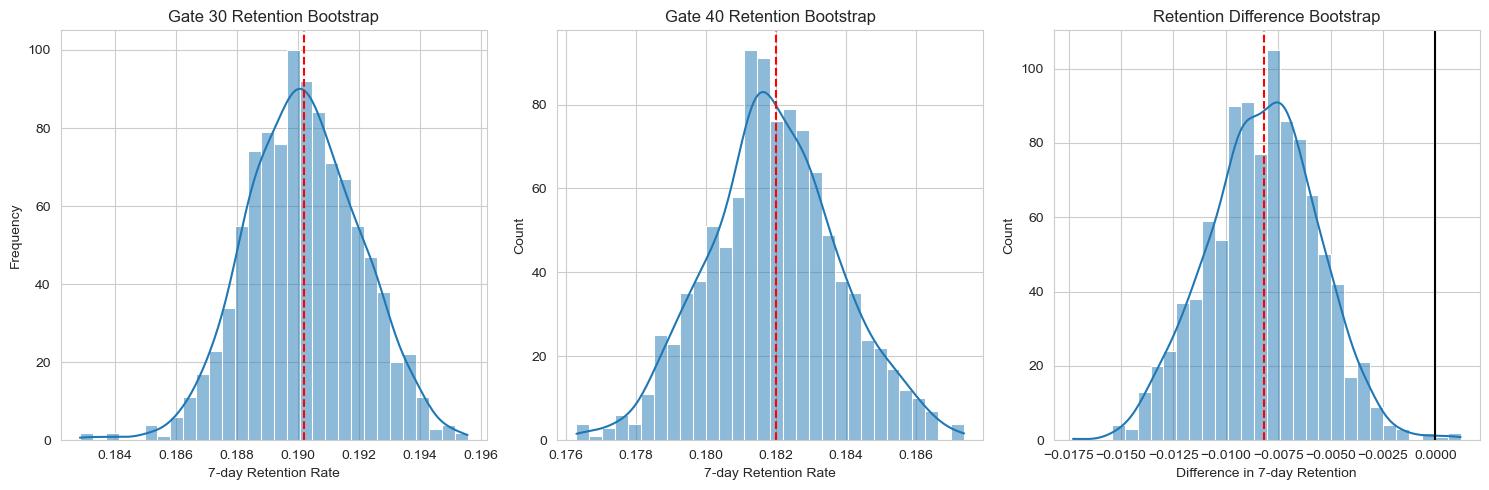

In [9]:
# Plot bootstrap distributions
plt.figure(figsize=(15, 5))

# Gate 30 distribution
plt.subplot(1, 3, 1)
sns.histplot(boot_30, bins=30, kde=True)
plt.axvline(retention_30, color='red', linestyle='--', label='Observed')
plt.title('Gate 30 Retention Bootstrap')
plt.xlabel('7-day Retention Rate')
plt.ylabel('Frequency')

# Gate 40 distribution
plt.subplot(1, 3, 2)
sns.histplot(boot_40, bins=30, kde=True)
plt.axvline(retention_40, color='red', linestyle='--', label='Observed')
plt.title('Gate 40 Retention Bootstrap')
plt.xlabel('7-day Retention Rate')

# Difference distribution
plt.subplot(1, 3, 3)
sns.histplot(boot_diff, bins=30, kde=True)
plt.axvline(observed_diff, color='red', linestyle='--', label='Observed')
plt.axvline(0, color='black', linestyle='-', label='No Difference')
plt.title('Retention Difference Bootstrap')
plt.xlabel('Difference in 7-day Retention')

plt.tight_layout()
plt.show()

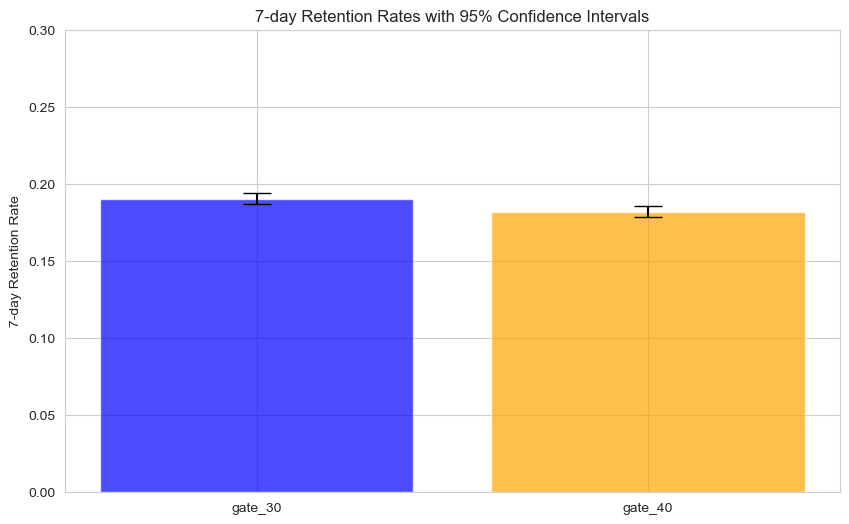

In [10]:
# Visualize confidence intervals
plt.figure(figsize=(10, 6))

# Plot observed retention rates
plt.bar(['gate_30', 'gate_40'], [retention_30, retention_40], 
        yerr=[[retention_30 - ci_30[0], retention_40 - ci_40[0]], 
              [ci_30[1] - retention_30, ci_40[1] - retention_40]],
        capsize=10, color=['blue', 'orange'], alpha=0.7)

plt.title('7-day Retention Rates with 95% Confidence Intervals')
plt.ylabel('7-day Retention Rate')
plt.ylim(0, 0.3)
plt.show()

## 6. Interpretation

In [11]:
print("""Interpretation of Results:
1. Confidence Intervals:
   - If the 95% CI for the difference includes 0, the result is not statistically significant
   - If the 95% CI for the difference excludes 0, the result is statistically significant

2. p-value:
   - p-value < 0.05 typically indicates statistical significance
   - p-value >= 0.05 suggests no statistically significant difference

3. Practical Significance:
   - Even if statistically significant, consider whether the magnitude of difference is meaningful

Based on the analysis:
- Observed difference: {observed_diff:.4f}
- 95% CI for difference: [{ci_diff[0]:.4f}, {ci_diff[1]:.4f}]
- p-value: {p_value:.4f}""".format(observed_diff=observed_diff, ci_diff=ci_diff, p_value=p_value))

Interpretation of Results:
1. Confidence Intervals:
   - If the 95% CI for the difference includes 0, the result is not statistically significant
   - If the 95% CI for the difference excludes 0, the result is statistically significant

2. p-value:
   - p-value < 0.05 typically indicates statistical significance
   - p-value >= 0.05 suggests no statistically significant difference

3. Practical Significance:
   - Even if statistically significant, consider whether the magnitude of difference is meaningful

Based on the analysis:
- Observed difference: -0.0082
- 95% CI for difference: [-0.0134, -0.0033]
- p-value: 0.4920


## 7. Next Steps

In [12]:
print("""Next steps:
1. Create comprehensive visualizations for reporting
2. Build machine learning models to predict retention
3. Augment data with external industry benchmarks
4. Refactor code into modular Python scripts""")

Next steps:
1. Create comprehensive visualizations for reporting
2. Build machine learning models to predict retention
3. Augment data with external industry benchmarks
4. Refactor code into modular Python scripts
